project:
business data(restaurants---locations---item,profits,sales,quantity)
insights

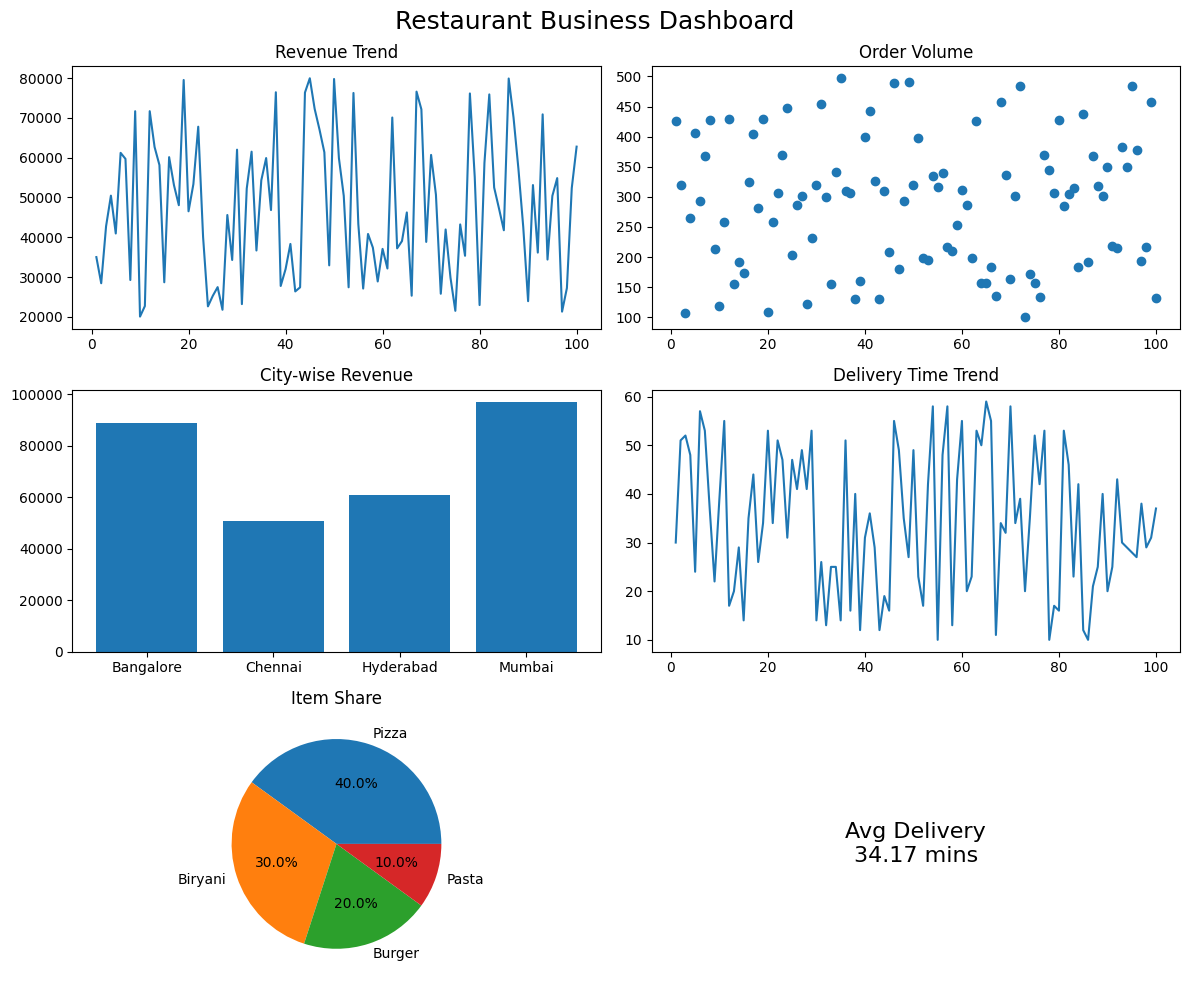

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(40)


# SYNTHETIC DATA


days = np.arange(1,101)

orders = np.random.randint(100,500,100)
delivery_time = np.random.randint(10,60,100)
revenue = np.random.randint(20000,80000,100)

cities = ["Bangalore","Chennai","Hyderabad","Mumbai"]
city_sales = np.random.randint(50000,200000,4)

items = ["Pizza","Biryani","Burger","Pasta"]
item_share = [40,30,20,10]

avg_delivery = np.mean(delivery_time)


# DASHBOARD


fig = plt.figure(figsize=(12,10))

# Revenue Trend
plt.subplot(3,2,1)
plt.plot(days,revenue)
plt.title("Revenue Trend")

# Orders Scatter
plt.subplot(3,2,2)
plt.scatter(days,orders)
plt.title("Order Volume")

# City Revenue
plt.subplot(3,2,3)
plt.bar(cities,city_sales)
plt.title("City-wise Revenue")

# Delivery Time
plt.subplot(3,2,4)
plt.plot(days,delivery_time)
plt.title("Delivery Time Trend")

# Item Share
plt.subplot(3,2,5)
plt.pie(item_share,labels=items,autopct='%1.1f%%')
plt.title("Item Share")

# KPI
plt.subplot(3,2,6)
plt.text(0.5,0.5,f"Avg Delivery\n{avg_delivery:.2f} mins",
         ha='center',va='center',fontsize=16)
plt.axis('off')

plt.suptitle("Restaurant Business Dashboard",fontsize=18)
plt.tight_layout()
plt.show()

Insights:

The business has strong demand but shows variability in orders and delivery efficiency.

Focusing on high-revenue cities, optimizing delivery time, and promoting popular items can improve overall performance.

In [5]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio



np.random.seed(40)

# ----------------------------
# SYNTHETIC DATA
# ----------------------------

days = np.arange(1,101)

cities = ["Bangalore","Chennai","Hyderabad","Mumbai"]

orders = np.random.randint(100,500,100)
delivery_time = np.random.randint(10,60,100)
revenue = np.random.randint(20000,80000,100)

city_sales = np.random.randint(50000,200000,4)

# ----------------------------
# DASHBOARD
# ----------------------------

fig = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"colspan":2}, None],
        [{"type":"scatter"},{"type":"bar"}],
        [{"type":"pie"},{"type":"indicator"}]
    ],
    subplot_titles=(
        "Daily Revenue Trend",
        "Order Volume",
        "City-wise Revenue",
        "Item Category Share",
        "Avg Delivery Time"
    )
)

# TOP TREND
fig.add_trace(go.Scatter(x=days, y=revenue, name="Revenue"), row=1, col=1)

# ORDERS
fig.add_trace(go.Scatter(x=days, y=orders, mode="markers"), row=2, col=1)

# CITY REVENUE
fig.add_trace(go.Bar(x=cities, y=city_sales), row=2, col=2)

# ITEM SHARE
fig.add_trace(go.Pie(labels=["Pizza","Biryani","Burger","Pasta"],
                     values=[40,30,20,10], hole=0.4), row=3, col=1)

# KPI
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=np.mean(delivery_time),
    title={'text':"Avg Delivery Time"},
    gauge={'axis':{'range':[0,60]}}
), row=3, col=2)

fig.update_xaxes(rangeslider_visible=True, row=1, col=1)

fig.update_layout(
    height=850,
    width=900,
    title="Restaurant Business Dashboard",
    template="plotly_dark"
)

fig.show()

In [3]:
# ==============================
# RESTAURANT BUSINESS DASHBOARD PROJECT
# ==============================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(42)

# ------------------------------
# 1. CREATE SYNTHETIC DATA
# ------------------------------

n = 1000

data = pd.DataFrame({
    "Restaurant": np.random.choice(["Spice Hub","Urban Bites","Food Palace","Tandoori Treats","Cafe Bliss"], n),
    "City": np.random.choice(["Bangalore","Chennai","Hyderabad","Mumbai","Delhi"], n),
    "Item": np.random.choice(["Burger","Pizza","Biryani","Pasta","Sandwich","Fries"], n),
    "Quantity_Sold": np.random.randint(1, 50, n),
    "Price": np.random.randint(100, 500, n),
    "Cost": np.random.randint(50, 300, n),
    "Date": pd.date_range(start="2025-01-01", periods=n, freq='D')
})

data["Sales"] = data["Quantity_Sold"] * data["Price"]
data["Profit"] = data["Sales"] - (data["Quantity_Sold"] * data["Cost"])

# ------------------------------
# 2. ADD REAL-WORLD ISSUES
# ------------------------------

data.loc[np.random.choice(data.index, 50), 'Price'] = np.nan
data.loc[np.random.choice(data.index, 30), 'Quantity_Sold'] = np.nan

# Add duplicates
data = pd.concat([data, data.iloc[0:10]])

print("\nNull values before cleaning:\n", data.isnull().sum())
print("\nDuplicate rows before cleaning:", data.duplicated().sum())

# ------------------------------
# 3. DATA CLEANING
# ------------------------------

data['Price'].fillna(data['Price'].mean(), inplace=True)
data['Quantity_Sold'].fillna(data['Quantity_Sold'].median(), inplace=True)

data.drop_duplicates(inplace=True)

print("\nNull values after cleaning:\n", data.isnull().sum())
print("\nDuplicate rows after cleaning:", data.duplicated().sum())

# Recalculate
data["Sales"] = data["Quantity_Sold"] * data["Price"]
data["Profit"] = data["Sales"] - (data["Quantity_Sold"] * data["Cost"])

# ------------------------------
# 4. FEATURE ENGINEERING
# ------------------------------

data["Month"] = data["Date"].dt.month
data["Profit_Margin"] = (data["Profit"] / data["Sales"]) * 100

# ------------------------------
# 5. AGGREGATIONS
# ------------------------------

sales_city = data.groupby("City")["Sales"].sum()
profit_rest = data.groupby("Restaurant")["Profit"].sum()
top_items = data.groupby("Item")["Quantity_Sold"].sum()
monthly_sales = data.groupby("Month")["Sales"].sum()
margin_city = data.groupby("City")["Profit_Margin"].mean()

# ------------------------------
# 6. ONE SCREEN DASHBOARD
# ------------------------------

fig = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"type":"bar"}, {"type":"domain"}],
        [{"type":"bar"}, {"type":"xy"}],
        [{"type":"bar"}, None]
    ],
    subplot_titles=[
        "Sales by City",
        "Profit by Restaurant",
        "Top Selling Items",
        "Monthly Sales Trend",
        "Profit Margin by City",
        ""
    ]
)

# Sales by City
fig.add_trace(go.Bar(x=sales_city.index, y=sales_city.values), row=1, col=1)

# Profit by Restaurant (Pie)
fig.add_trace(go.Pie(labels=profit_rest.index, values=profit_rest.values), row=1, col=2)

# Top Selling Items
fig.add_trace(go.Bar(x=top_items.index, y=top_items.values), row=2, col=1)

# Monthly Sales Trend
fig.add_trace(go.Scatter(x=monthly_sales.index, y=monthly_sales.values, mode='lines+markers'), row=2, col=2)

# Profit Margin by City
fig.add_trace(go.Bar(x=margin_city.index, y=margin_city.values), row=3, col=1)

fig.update_layout(
    height=850,
    width=1200,
    title_text="Restaurant Business Performance Dashboard",
    showlegend=False
)

fig.show()

# ------------------------------
# 7. BUSINESS INSIGHTS
# ------------------------------

print("\n================ BUSINESS INSIGHTS ================\n")

print("Top Revenue City:", sales_city.idxmax())
print("Most Profitable Restaurant:", profit_rest.idxmax())
print("Top Selling Item:", top_items.idxmax())
print("Lowest Margin City:", margin_city.idxmin())
print("Peak Sales Month:", monthly_sales.idxmax())

print("\nSuggestions:")
print("- Expand in top revenue city")
print("- Promote best selling item")
print("- Optimize costs in low margin city")
print("- Introduce offers in low performing months")

print("\n===================================================")


Null values before cleaning:
 Restaurant        0
City              0
Item              0
Quantity_Sold    29
Price            49
Cost              0
Date              0
Sales             0
Profit            0
dtype: int64

Duplicate rows before cleaning: 10

Null values after cleaning:
 Restaurant       0
City             0
Item             0
Quantity_Sold    0
Price            0
Cost             0
Date             0
Sales            0
Profit           0
dtype: int64

Duplicate rows after cleaning: 0


/tmp/ipython-input-473/3989020058.py:48: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipython-input-473/3989020058.py:49: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=T


================ BUSINESS INSIGHTS ================

Top Revenue City: Chennai
Most Profitable Restaurant: Cafe Bliss
Top Selling Item: Pasta
Lowest Margin City: Hyderabad
Peak Sales Month: 1

Suggestions:
- Expand in top revenue city
- Promote best selling item
- Optimize costs in low margin city
- Introduce offers in low performing months



In [4]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(40)

# ----------------------------
# SYNTHETIC DATA
# ----------------------------

days = np.arange(1,101)

restaurants = ["Spice Hub","Urban Bites","Food Palace","Tandoori Treats"]
cities = ["Bangalore","Chennai","Hyderabad","Mumbai"]

orders = np.random.randint(100,500,100)
delivery_time = np.random.randint(10,60,100)
revenue = np.random.randint(20000,80000,100)

category_sales = np.random.randint(50000,200000,4)

# ----------------------------
# DASHBOARD LAYOUT
# ----------------------------

fig = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"colspan":2}, None],
        [{"type":"scatter"},{"type":"bar"}],
        [{"type":"pie"},{"type":"indicator"}]
    ],
    subplot_titles=(
        "Daily Revenue Trend",
        "Order Volume",
        "City-wise Revenue",
        "Item Category Share",
        "Avg Delivery Time"
    )
)

# ----------------------------
# TOP: TREND
# ----------------------------

fig.add_trace(
    go.Scatter(x=days, y=revenue, name="Revenue"),
    row=1, col=1
)

# ----------------------------
# MIDDLE LEFT: ORDERS
# ----------------------------

fig.add_trace(
    go.Scatter(x=days, y=orders, mode="markers", name="Orders"),
    row=2, col=1
)

# ----------------------------
# MIDDLE RIGHT: CITY REVENUE
# ----------------------------

fig.add_trace(
    go.Bar(x=cities, y=category_sales, name="Revenue"),
    row=2, col=2
)

# ----------------------------
# BOTTOM LEFT: ITEM SHARE
# ----------------------------

fig.add_trace(
    go.Pie(
        labels=["Pizza","Biryani","Burger","Pasta"],
        values=[40,30,20,10],
        hole=0.4
    ),
    row=3, col=1
)

# ----------------------------
# BOTTOM RIGHT: KPI
# ----------------------------

fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=np.mean(delivery_time),
        title={'text':"Avg Delivery Time"},
        gauge={'axis':{'range':[0,60]}}
    ),
    row=3, col=2
)

# ----------------------------
# SLIDER FOR TREND
# ----------------------------

fig.update_xaxes(rangeslider_visible=True, row=1, col=1)

# ----------------------------
# FINAL LAYOUT
# ----------------------------

fig.update_layout(
    height=850,
    width=900,
    title="Restaurant Business Dashboard",
    template="plotly_dark"
)

fig.show()